In [1]:
# Get the stock historical data from Interactive brokers using ib_insync
from ib_insync import *
import pandas as pd

ib = IB()
util.startLoop()
ib.connect('127.0.0.1', 7497, clientId=28)

<IB connected to 127.0.0.1:7497 clientId=28>

In [2]:
symbol = input("Enter the stock symbol: ")
duration = input("Enter the duration (e.g., '1 M', '1 D'): ")
bar_size = input("Enter the bar size (e.g '1 min', or day and year'): )")

In [3]:
Contract = Stock(symbol=symbol, exchange='SMART', currency='USD')
bars = ib.reqHistoricalData(
        Contract,
        endDateTime='',
        durationStr=duration,
        barSizeSetting=bar_size,
        whatToShow="TRADES",
        useRTH=True,
        formatDate=1
    )

ib.disconnect()

In [4]:
# save the data to a CSV file
df = util.df(bars)



In [5]:
df.to_csv(f"{symbol}_historical_data.csv", index=False)

In [6]:
df.head()

,date,open,high,low,close,volume,average,barCount
0,2021-01-04,354.98,354.98,341.06,344.64,1043582.0,345.876,6507
1,2021-01-05,344.64,351.19,343.30,348.79,791824.0,347.595,5116
2,2021-01-06,343.00,351.92,342.78,348.03,1169597.0,346.394,8037
3,2021-01-07,344.36,347.85,341.33,342.55,1240922.0,343.276,7444
4,2021-01-08,341.88,343.47,335.01,336.10,1960874.0,337.477,11504


In [7]:
df.describe()

,open,high,low,close,volume,average,barCount
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03,1256.000000,1256.000000
mean,441.361441,445.230104,437.518503,441.416982,6.348061e+05,441.419430,4514.922771
std,56.809469,57.205004,56.288810,56.745345,4.501403e+05,56.663348,2961.472059
min,324.880000,325.650000,319.810000,321.820000,9.586200e+04,323.472000,712.000000
25%,403.675000,407.620000,398.012500,403.997500,3.789228e+05,403.195750,2717.250000
50%,449.955000,453.075000,445.895000,449.385000,5.179695e+05,449.239000,3730.500000
75%,471.000000,475.302500,466.765000,470.552500,7.473368e+05,471.153500,5387.000000
max,615.640000,618.950000,611.360000,614.610000,6.246056e+06,614.020000,36581.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      1256 non-null   object 
 1   open      1256 non-null   float64
 2   high      1256 non-null   float64
 3   low       1256 non-null   float64
 4   close     1256 non-null   float64
 5   volume    1256 non-null   float64
 6   average   1256 non-null   float64
 7   barCount  1256 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 78.6+ KB


In [9]:
df["date"].value_counts()

date
2026-01-02    1
2021-01-04    1
2021-01-05    1
2021-01-06    1
2021-01-07    1
             ..
2021-01-21    1
2021-01-20    1
2021-01-19    1
2021-01-15    1
2021-01-14    1
Name: count, Length: 1256, dtype: int64

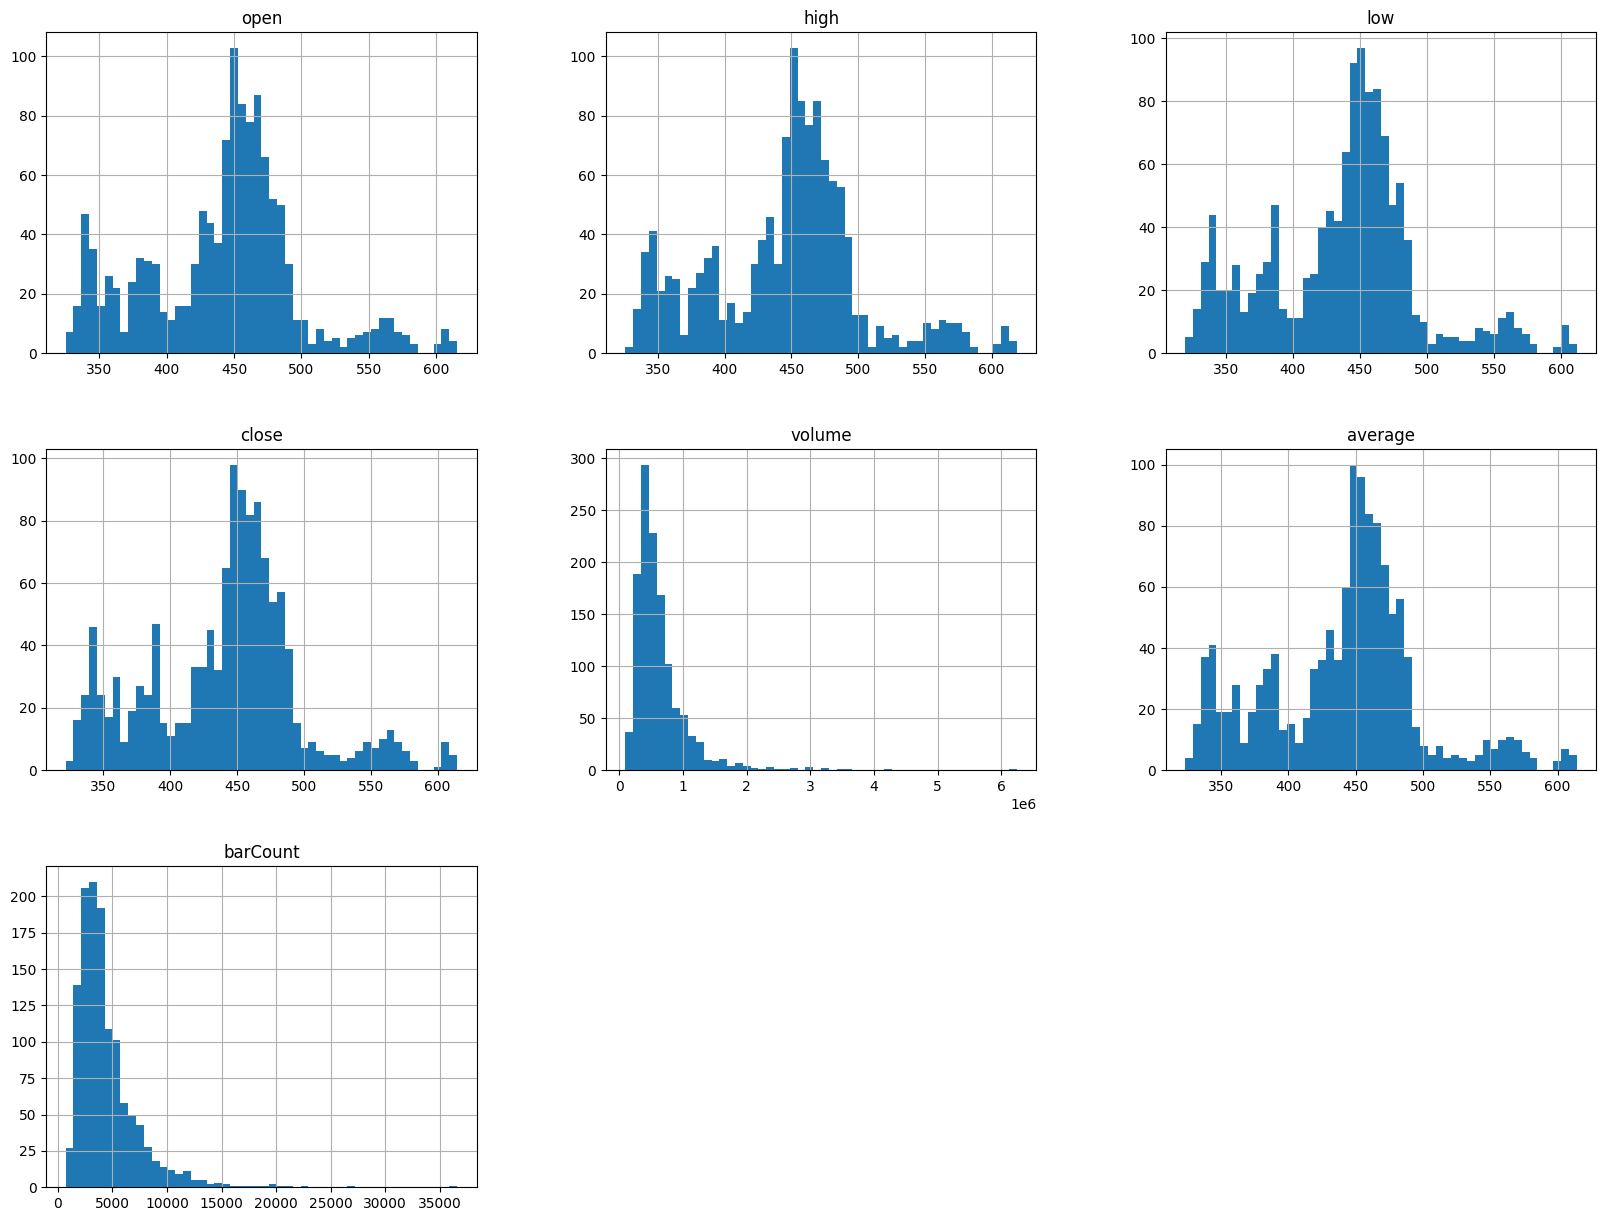

In [10]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)




In [12]:
corr_matrix = df.corr(numeric_only=True)


In [13]:
corr_matrix["close"].sort_values(ascending=False)

close       1.000000
average     0.999419
low         0.998200
high        0.998004
open        0.996015
barCount   -0.283243
volume     -0.298055
Name: close, dtype: float64

In [14]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
ordinal_encoder = OrdinalEncoder()
df_date_encoded = ordinal_encoder.fit_transform(df[["date"]])

In [15]:
df_date_encoded[:10]

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.],
       [6.],
       [7.],
       [8.],
       [9.]])

In [16]:
ordinal_encoder.categories_

[array([datetime.date(2021, 1, 4), datetime.date(2021, 1, 5),
        datetime.date(2021, 1, 6), ..., datetime.date(2025, 12, 30),
        datetime.date(2025, 12, 31), datetime.date(2026, 1, 2)],
       dtype=object)]

In [17]:
std_scaler = StandardScaler()
housing_num_scaled = std_scaler.fit_transform(df[['open', 'high', 'low', 'average']])

In [18]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
model = TransformedTargetRegressor(regressor=LinearRegression(), transformer=std_scaler)
model.fit(df[['open', 'high', 'low', 'average']], df['close'])
predictions = model.predict(df[['open', 'high', 'low', 'average']])
predictions[:10]

array([343.86679141, 347.75417529, 345.56173796, 342.09064637,
       335.8666832 , 337.7048188 , 339.86262867, 343.84613746,
       352.03100791, 347.04041134])

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
tree_reg = make_pipeline(StandardScaler(), DecisionTreeRegressor(random_state=42))
features = df[['open', 'high', 'low', 'average']]
target = df['close']
tree_reg.fit(features, target)


,steps,"[('standardscaler', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [20]:
tree_predictions = tree_reg.predict(features)
from sklearn.metrics import root_mean_squared_error
tree_rmse = root_mean_squared_error(target, tree_predictions)

In [21]:
tree_rmse

0.0

In [22]:
from sklearn.model_selection import cross_val_score
tree_rmse = -cross_val_score(tree_reg, features, target,
                             scoring="neg_root_mean_squared_error", cv=10)

In [23]:
import pandas as pd

In [24]:
pd.Series(tree_rmse).describe()

count    10.000000
mean      7.134648
std      14.096182
min       2.069488
25%       2.340903
50%       2.736400
75%       3.197724
max      47.234234
dtype: float64

In [25]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42))
forest_rmse = -cross_val_score(forest_reg, features, target, scoring="neg_root_mean_squared_error", cv=10)

In [26]:
pd.Series(forest_rmse).describe()

count    10.000000
mean      6.669400
std      14.481261
min       1.466312
25%       1.653228
50%       2.091533
75%       2.707047
max      47.855075
dtype: float64

In [27]:
tree_predictions

array([344.64, 348.79, 348.03, ..., 488.  , 483.67, 497.07])